# Feature Selection with MRMR
### Combined dataset, pain_reduction target and T1-T2 timepoint patients

In [1]:
import sys, os
sys.path.insert(0, '../src')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from skrub import TableReport
import joblib, os
import preprocess
import explore
import model
import feature_selection
from sklearn.preprocessing import PowerTransformer
import joblib
import importlib
import feature_selection


os.environ['PYTHONWARNINGS'] = 'ignore'

MODEL_DIR = os.path.abspath('../models')


In [2]:
# Running through preprocessing steps
# Load raw data
df_im, df_cl = explore.load_data()

# Clean datasets
_im_id_cols = ['Patient', 'Timepoint', 'Date']
df_im_vis   = preprocess.clean_im(df_im, False)
df_cl_vis   = preprocess.clean_cl(df_cl, False)

# Immunological: drop >25% NaN columns, remove confirmed outliers
df_im_mod    = preprocess.remove_nan_cols(df_im_vis, verbose=False)
df_im_mod    = preprocess.remove_outlier_observations(df_im_mod, verbose=False)
df_im_mod    = preprocess.remove_for_modeling(df_im_mod, verbose=False)

# Clinical: drop >25% NaN columns
df_cl_mod    = preprocess.remove_nan_cols(df_cl_vis, verbose=False)
df_cl_mod    = preprocess.remove_for_modeling(df_cl_mod, verbose=False)

print(f"df_im_mod : {df_im_mod.shape}")
print(f"df_cl_mod : {df_cl_mod.shape}")


df_im_mod : (814, 77)
df_cl_mod : (842, 26)


In [3]:
# Constructing targets:
print('\nConstructing regression targets from clinical data')
pain_targets       = model.construct_datasets_targets(df_cl_mod, 'pain_scale',      [1, 2])
targets_under_load = model.construct_datasets_targets(df_cl_mod, 'pain_under_load', [1, 2])


Constructing regression targets from clinical data

  Target distributions:
    pain_reduction                              mean=1.347  std=2.051  [-4.000, 7.100]
    pain_reduction_pct                          mean=19.196  std=32.847  [-100.000, 87.654]

  Target distributions:
    pain_under_load_reduction                   mean=0.551  std=0.753  [-1.000, 3.000]
    pain_under_load_reduction_pct               mean=14.125  std=20.231  [-50.000, 75.000]


## Dataset Overview

In [4]:
print('\nConstructing datasets for modeling:')
# Construct model datasets for each target type:
_unique_targets = {
    'pain_reduction':            pain_targets,
    'pain_under_load_reduction': targets_under_load,
}

model_datasets = {}
for tgt, tdf in _unique_targets.items():
    model_datasets[tgt] = model.create_model_datasets(
        df_cl_mod, df_im_mod, tdf, timepoints=[1, 2]
    )
model_datasets['pain_reduction_pct'] = model_datasets['pain_reduction']



Constructing datasets for modeling:

Total Number of Clinical features: 24
  Dropping 7 Columns before modeling: ['morning_stiffness', 'pain_at_rest', 'pain_daytime', 'pain_night', 'pain_scale', 'pain_under_load', 'response']
  Dropped baseline target cols : ['pain_scale_t1']

Modeling datasets ready: (T1–T2 immunological data + clinical baseline variables:
Shape of Combined Dataset: (116, 95), Number of Patients: 116

Total Number of Clinical features: 24
  Dropping 7 Columns before modeling: ['morning_stiffness', 'pain_at_rest', 'pain_daytime', 'pain_night', 'pain_scale', 'pain_under_load', 'response']
  Dropped baseline target cols : ['pain_under_load_t1']

Modeling datasets ready: (T1–T2 immunological data + clinical baseline variables:
Shape of Combined Dataset: (115, 95), Number of Patients: 115


## MRMR Feature Frequency List

### Target: pain_reduction 

In [15]:
import feature_selection

mrmr_freq = feature_selection.get_mrmr_frequency(
        model_datasets['pain_reduction'],
        target_col='pain_reduction',
        random_state=42,
        K=20)

# Save feature frequency list 
joblib.dump(mrmr_freq, os.path.join(MODEL_DIR, 'mrmr_freq.pkl'))
print(' Saved feature frequency list')



  MRMR Feature Frequency — pain_reduction
  n=116, p=92, K=20
  Outer CV: RepeatedKFold(n_splits=4, n_repeats=5) = 20 folds
 Outer Fold  1/20 — 20 features: ['Monocytes_t2_minus_t1', 'TREGs_t2_minus_t1', 'B cells_t2_minus_t1', 'mDC-1_t2_minus_t1', 'Mo1_t2_minus_t1', 'NKT_56+/16+_t2_minus_t1']...
 Outer Fold  2/20 — 20 features: ['PMN_t2_minus_t1', 'Neutrophils_t2_minus_t1', 'Eosinophils_t2_minus_t1', 'Basophils_t2_minus_t1', 'CD123lo Bas_t2_minus_t1', 'Monocytes_t2_minus_t1']...
 Outer Fold  3/20 — 20 features: ['TREGs_t2_minus_t1', 'T8lo_t2_minus_t1', 'NK4_t2_minus_t1', 'mDC-1_t2_minus_t1', 'mDC-2_t2_minus_t1', 'Mo2_t2_minus_t1']...
 Outer Fold  4/20 — 20 features: ['Neutrophils_t2_minus_t1', 'TREGs_t2_minus_t1', 'NK3_t2_minus_t1', 'mDC-1_t2_minus_t1', 'NKT_56+_t2_minus_t1', 'BAS_CD25+_t2_minus_t1']...
 Outer Fold  5/20 — 20 features: ['PMN_t2_minus_t1', 'Eosinophils_t2_minus_t1', 'Monocytes_t2_minus_t1', 'NKT_t2_minus_t1', 'T8lo_t2_minus_t1', 'DPT_t2_minus_t1']...
 Outer Fold  6/20 

In [13]:
importlib.reload(feature_selection)
mrmr_freq = joblib.load(os.path.join(MODEL_DIR, 'mrmr_freq.pkl'))
pt = PowerTransformer(method='yeo-johnson', standardize=True)

sweep_df, sweep_results = feature_selection.run_enet_threshold(
    model_datasets['pain_reduction'],
    mrmr_freq,
    target_col='pain_reduction',
    random_state=42,
    target_transformer=pt,
)

import joblib
joblib.dump(sweep_results, os.path.join(MODEL_DIR,'sweep_results.joblib'))
joblib.dump(sweep_df, os.path.join(MODEL_DIR, 'sweep_df.joblib'))


  Threshold: ALL features — 92 features
  ['PMN_t2_minus_t1', 'Neutrophils_t2_minus_t1', 'Eosinophils_t2_minus_t1', 'Basophils_t2_minus_t1', 'CD123lo Bas_t2_minus_t1', 'Monocytes_t2_minus_t1', 'T cells_t2_minus_t1', 'TH_t2_minus_t1']...
  Outer Fold  1/20 | Best Trial  2/50  RMSE=0.9939  {'alpha': 8.995870550626835, 'l1_ratio': 0.9211180955866348}
  Outer Fold  2/20 | Best Trial  6/50  RMSE=0.9993  {'alpha': 4.483589772690633, 'l1_ratio': 0.14178145073823412}
  Outer Fold  3/20 | Best Trial 11/50  RMSE=1.0042  {'alpha': 1.1407762316224914, 'l1_ratio': 0.5973860512538922}
  Outer Fold  4/20 | Best Trial  4/50  RMSE=1.0076  {'alpha': 2.7022281858965664, 'l1_ratio': 0.4271005337321133}
  Outer Fold  5/20 | Best Trial  1/50  RMSE=0.9997  {'alpha': 0.8912711464739217, 'l1_ratio': 0.5666692618458457}
  Outer Fold  6/20 | Best Trial 11/50  RMSE=1.0011  {'alpha': 5.856422154745774, 'l1_ratio': 0.36179546039319327}
  Outer Fold  7/20 | Best Trial  1/50  RMSE=0.9986  {'alpha': 4.346173319113583

['p:\\UK_Erlangen\\Student_folders\\Muna Ahmed Farah - IMMO-LDRT01\\master-thesis\\models\\sweep_df.joblib']

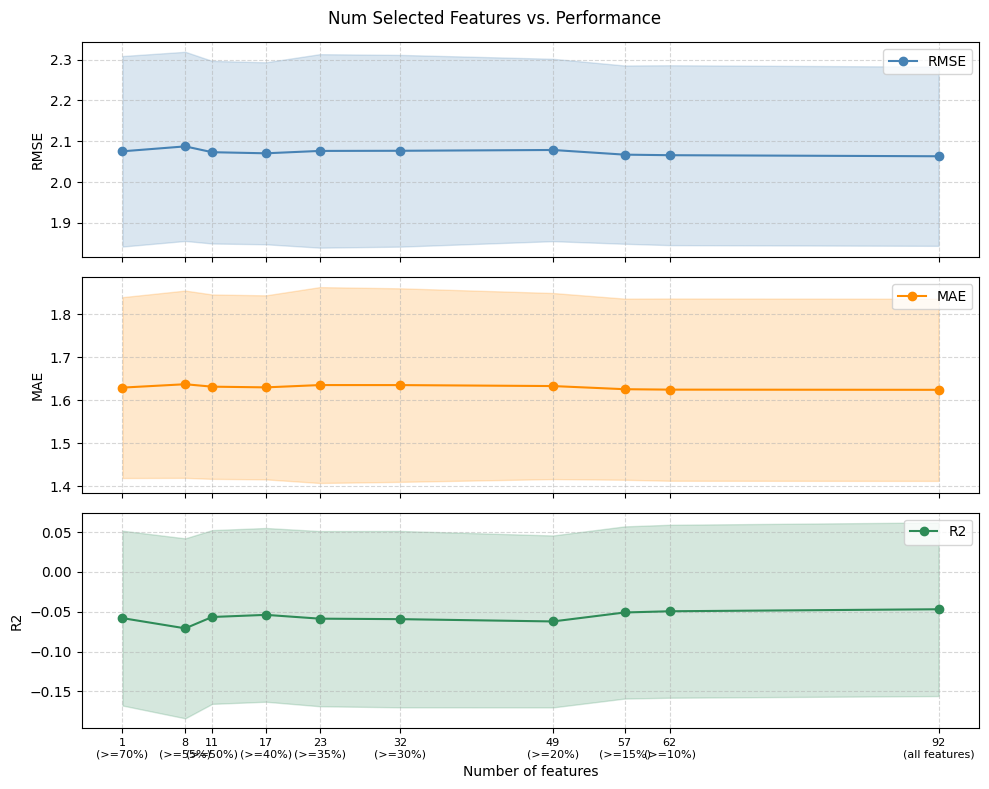

In [20]:
import matplotlib.pyplot as plt
import numpy as np
import joblib
sweep_df = joblib.load(os.path.join(MODEL_DIR, 'sweep_df.joblib'))

fig, axes = plt.subplots(3, 1, figsize=(10, 8), sharex=True)

x     = sweep_df['n_features']
x_lab = sweep_df['threshold_label']

for ax, metric, color in zip(axes, ['RMSE', 'MAE', 'R2'], ['steelblue', 'darkorange', 'seagreen']):
    mean = sweep_df[f'mean_{metric}']
    std  = sweep_df[f'std_{metric}']
    ax.plot(x, mean, marker='o', color=color, label=metric)
    ax.fill_between(x, mean - std, mean + std, alpha=0.2, color=color)
    ax.set_ylabel(metric)
    ax.legend(loc='upper right')
    ax.grid(True, linestyle='--', alpha=0.5)

axes[-1].set_xlabel('Number of features')
axes[-1].set_xticks(x)
axes[-1].set_xticklabels([f"{n}\n({t})" for n, t in zip(x, x_lab)], fontsize=8)

plt.suptitle('Num Selected Features vs. Performance', fontsize=12)
plt.tight_layout()
plt.show()


In [21]:
# Selected Features for modeling
top_features_list = mrmr_freq[mrmr_freq >= 0.50].index.tolist()
joblib.dump(top_features_list, os.path.join(MODEL_DIR,'top_features_list.pkl'))

print("Feature Selection for Modeling: Features selected in >50% of folds:")
print(mrmr_freq[mrmr_freq >= 0.50])


Feature Selection for Modeling: Features selected in >50% of folds:
feature
TC CM_PD1+_t2_minus_t1     0.70
mDC-1_t2_minus_t1          0.65
CD123lo Bas_t2_minus_t1    0.55
Mo2_HLADR+_t2_minus_t1     0.55
TREGs_t2_minus_t1          0.55
TC_PD1+_t2_minus_t1        0.55
BAS_CD25+_t2_minus_t1      0.55
weight_kg                  0.55
Neu_HLADR+_t2_minus_t1     0.50
NK3_t2_minus_t1            0.50
height_cm                  0.50
Name: selection_freq, dtype: float64
